In [ ]:
# Install all required libraries — every notebook is self-contained
!pip install fastapi uvicorn scikit-fem nest-asyncio requests pyngrok meshio -q

import nest_asyncio
nest_asyncio.apply()

print("✅ Libraries installed and nest-asyncio applied")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 6.4 MB/s eta 0:00:00
✅ Libraries installed and nest-asyncio applied


In [ ]:
import os
import json
import time
import logging
import threading
import requests
import asyncio
import uvicorn
import numpy as np
from datetime import datetime
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import Optional, List
from uvicorn import Config, Server
from google.colab import drive

# scikit-fem imports
from skfem import (
    MeshQuad,
    Basis,
    ElementTriP1,
    ElementVector,
    FacetBasis,
    asm,
    solve,
    condense
)
from skfem.models.elasticity import linear_elasticity

# Mount Drive
drive.mount('/content/drive')

# Define paths
DRIVE_PATH = '/content/drive/MyDrive/MCL_Orchestrator/'

PATHS = {
    'notebooks' : f'{DRIVE_PATH}notebooks/',
    'services'  : f'{DRIVE_PATH}services/',
    'results'   : f'{DRIVE_PATH}results/',
    'logs'      : f'{DRIVE_PATH}logs/',
    'docs'      : f'{DRIVE_PATH}docs/'
}

# Confirm folders
print("\nConfirming Drive folder structure:")
print("=" * 45)
all_exist = True
for name, path in PATHS.items():
    exists = os.path.exists(path)
    status = "✅ Found" if exists else "❌ Missing"
    print(f"  {name:<12} : {status}")
    if not exists:
        all_exist = False

print("=" * 45)
if all_exist:
    print("✅ All folders confirmed")
    print(f"   scikit-fem imported successfully")
else:
    print("❌ Some folders missing — check Drive before continuing")

Mounted at /content/drive

Confirming Drive folder structure:
  notebooks    : ✅ Found
  services     : ✅ Found
  results      : ✅ Found
  logs         : ✅ Found
  docs         : ✅ Found
✅ All folders confirmed
   scikit-fem imported successfully


In [ ]:
# ── Logger ────────────────────────────────────────────────────────
log_file_path = f'{DRIVE_PATH}logs/pipeline.log'

# Create log file if it doesn't exist
if not os.path.exists(log_file_path):
    with open(log_file_path, 'w') as f:
        f.write(f"MCL Orchestrator — Pipeline Log\n")
        f.write(f"Created : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("=" * 60 + "\n")

# Named logger with handler guard
logger = logging.getLogger('MCL_Orchestrator')
logger.setLevel(logging.INFO)

if not logger.handlers:
    file_handler = logging.FileHandler(log_file_path)
    file_handler.setLevel(logging.INFO)
    file_handler.setFormatter(logging.Formatter(
        '%(asctime)s | %(levelname)s | %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    ))
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)
    console_handler.setFormatter(logging.Formatter(
        '%(asctime)s | %(levelname)s | %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    ))
    logger.addHandler(file_handler)
    logger.addHandler(console_handler)

def log_event(stage, status, detail=''):
    message = f"{stage:<30} | {status:<10} | {detail}"
    if status == 'ERROR':
        logger.error(message)
    elif status == 'WARNING':
        logger.warning(message)
    else:
        logger.info(message)

# ── Pipeline State ────────────────────────────────────────────────
state_file_path = f'{DRIVE_PATH}logs/pipeline_state.json'

pipeline_state = {
    'job_id'      : None,
    'started_at'  : None,
    'stages'      : {
        'A_parameter_generation': 'pending',
        'B_fem_simulation'      : 'pending',
        'C_postprocessing'      : 'pending'
    },
    'errors'      : [],
    'completed_at': None
}

def update_state(stage, status, error=None):
    pipeline_state['stages'][stage] = status
    if error:
        pipeline_state['errors'].append({
            'stage'    : stage,
            'error'    : str(error),
            'timestamp': datetime.now().isoformat()
        })
        log_event(stage, 'ERROR', str(error))
    else:
        log_event(stage, status, f"Stage updated to {status}")
    with open(state_file_path, 'w') as f:
        json.dump(pipeline_state, f, indent=4)

# ── Retry Handler ─────────────────────────────────────────────────
def post_with_retry(url, data, max_retries=3, backoff=2):
    log_event('retry_handler', 'INFO',
              f"POST to {url} | max_retries={max_retries}")
    for attempt in range(max_retries):
        try:
            response = requests.post(url, json=data, timeout=30)
            response.raise_for_status()
            log_event('retry_handler', 'SUCCESS',
                      f"POST succeeded on attempt {attempt + 1}")
            return response.json()
        except requests.exceptions.ConnectionError:
            if attempt < max_retries - 1:
                wait = backoff ** attempt
                print(f"  ⚠️  Service unreachable — retrying in {wait}s "
                      f"(attempt {attempt + 1}/{max_retries})")
                log_event('retry_handler', 'WARNING',
                          f"Connection failed — retrying in {wait}s")
                time.sleep(wait)
            else:
                log_event('retry_handler', 'ERROR',
                          f"Unreachable after {max_retries} attempts")
                raise RuntimeError(
                    f"❌ Service at {url} unreachable after {max_retries} attempts"
                )
        except requests.exceptions.Timeout:
            log_event('retry_handler', 'ERROR', f"Timeout at {url}")
            raise RuntimeError(f"❌ Service at {url} timed out")
        except requests.exceptions.HTTPError as e:
            log_event('retry_handler', 'ERROR', f"HTTP error: {e}")
            raise RuntimeError(f"❌ HTTP error: {e}")

# ── Confirmation ──────────────────────────────────────────────────
print("✅ Shared utilities reinitialised:")
print("   Logger        : ✅ handler guard active")
print("   State tracker : ✅ ready")
print("   Retry handler : ✅ ready")
log_event('02_service_B', 'INFO',
          'Shared utilities initialised in Notebook 3')

✅ Shared utilities reinitialised:
   Logger        : ✅ handler guard active
   State tracker : ✅ ready
   Retry handler : ✅ ready


2026-06-01 20:26:41 | INFO | 02_service_B                   | INFO       | Shared utilities initialised in Notebook 3
INFO:MCL_Orchestrator:02_service_B                   | INFO       | Shared utilities initialised in Notebook 3


In [ ]:
class SimulationInput(BaseModel):
    job_id                : str
    E_GPa                 : float   # Effective composite modulus (GPa)
    nu                    : float   # Poisson's ratio
    applied_stress        : float   # Applied tensile stress (MPa)
    length_mm             : float   # Coupon length (mm)
    width_mm              : float   # Coupon width (mm)
    fiber_volume_fraction : float   # Fiber volume fraction
    E_fiber_GPa           : float   # Raw fiber modulus — for traceability
    E_matrix_GPa          : float   # Raw matrix modulus — for traceability
    timestamp             : str     # Job creation time from Service A

# Print schema clearly
print("Simulation Input Schema — SimulationInput")
print("=" * 58)
print(f"  {'Field':<25} {'Type':<8} {'Source':<10} Description")
print("  " + "-" * 55)

fields_info = {
    'job_id'               : ('str',   'Service A', 'Unique pipeline run identifier'),
    'E_GPa'                : ('float', 'Service A', 'Effective modulus — Voigt rule of mixtures'),
    'nu'                   : ('float', 'Service A', "Poisson's ratio of composite"),
    'applied_stress'       : ('float', 'Service A', 'Applied tensile stress in MPa'),
    'length_mm'            : ('float', 'Service A', 'Coupon length in mm'),
    'width_mm'             : ('float', 'Service A', 'Coupon width in mm'),
    'fiber_volume_fraction': ('float', 'Service A', 'Fiber volume fraction'),
    'E_fiber_GPa'          : ('float', 'Service A', 'Raw fiber modulus for traceability'),
    'E_matrix_GPa'         : ('float', 'Service A', 'Raw matrix modulus for traceability'),
    'timestamp'            : ('str',   'Service A', 'Job creation timestamp')
}

for field, (ftype, source, desc) in fields_info.items():
    print(f"  {field:<25} {ftype:<8} {source:<10} {desc}")

print("=" * 58)

# Show a sample payload as it would arrive from Service A
sample_payload = SimulationInput(
    job_id                = 'SAMPLE01',
    E_GPa                 = 220.5,
    nu                    = 0.20,
    applied_stress        = 300.0,
    length_mm             = 100.0,
    width_mm              = 20.0,
    fiber_volume_fraction = 0.45,
    E_fiber_GPa           = 380.0,
    E_matrix_GPa          = 90.0,
    timestamp             = datetime.now().isoformat()
)

print(f"\n  Sample payload from Service A:")
print(f"  " + "-" * 45)
for field, value in sample_payload.dict().items():
    print(f"    {field:<25} : {value}")
print(f"  " + "-" * 45)
print(f"\n✅ SimulationInput schema defined")

Simulation Input Schema — SimulationInput
  Field                     Type     Source     Description
  -------------------------------------------------------
  job_id                    str      Service A  Unique pipeline run identifier
  E_GPa                     float    Service A  Effective modulus — Voigt rule of mixtures
  nu                        float    Service A  Poisson's ratio of composite
  applied_stress            float    Service A  Applied tensile stress in MPa
  length_mm                 float    Service A  Coupon length in mm
  width_mm                  float    Service A  Coupon width in mm
  fiber_volume_fraction     float    Service A  Fiber volume fraction
  E_fiber_GPa               float    Service A  Raw fiber modulus for traceability
  E_matrix_GPa              float    Service A  Raw matrix modulus for traceability
  timestamp                 str      Service A  Job creation timestamp

  Sample payload from Service A:
  ------------------------------------

/tmp/ipykernel_12771/3562770290.py:53: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  for field, value in sample_payload.dict().items():


Tensile Coupon Mesh — Statistics
  Coupon dimensions : 100.0 mm x 20.0 mm
  Element type      : Linear triangular (simplex)
  Elements (length) : 20
  Elements (width)  : 5
  Total elements    : 200
  Total nodes       : 126
  Aspect ratio      : 5.0:1


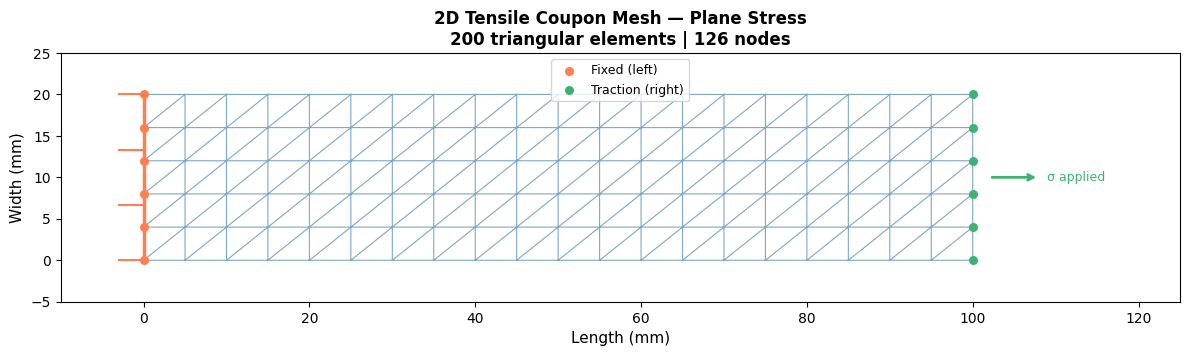


✅ Mesh confirmed and plot saved to Drive
   /content/drive/MyDrive/MCL_Orchestrator/results/mesh_plot.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from skfem import MeshTri

# Build the rectangular mesh
length_mm = 100.0
width_mm  = 20.0
n_length  = 20    # elements along length
n_width   = 5     # elements along width


mesh = MeshTri.init_tensor(
    np.linspace(0, length_mm, n_length + 1),
    np.linspace(0, width_mm,  n_width  + 1)
)

# Mesh statistics
n_nodes    = mesh.p.shape[1]
n_elements = mesh.t.shape[1]

print("Tensile Coupon Mesh — Statistics")
print("=" * 45)
print(f"  Coupon dimensions : {length_mm} mm x {width_mm} mm")
print(f"  Element type      : Linear triangular (simplex)")
print(f"  Elements (length) : {n_length}")
print(f"  Elements (width)  : {n_width}")
print(f"  Total elements    : {n_elements}")
print(f"  Total nodes       : {n_nodes}")
print(f"  Aspect ratio      : {length_mm/width_mm:.1f}:1")
print("=" * 45)

# Plot the mesh
fig, ax = plt.subplots(figsize=(12, 4))

# Plot triangular elements
triangulation = tri.Triangulation(
    mesh.p[0], mesh.p[1], mesh.t.T
)
ax.triplot(triangulation, color='steelblue',
           linewidth=0.8, alpha=0.7)

# Highlight boundary nodes
left_nodes  = np.where(mesh.p[0] < 1e-10)[0]
right_nodes = np.where(mesh.p[0] > length_mm - 1e-10)[0]

ax.scatter(mesh.p[0][left_nodes], mesh.p[1][left_nodes],
           color='coral', s=30, zorder=5, label='Fixed (left)')
ax.scatter(mesh.p[0][right_nodes], mesh.p[1][right_nodes],
           color='mediumseagreen', s=30, zorder=5,
           label='Traction (right)')

# Load arrow
ax.annotate('', xy=(length_mm + 8, width_mm / 2),
            xytext=(length_mm + 2, width_mm / 2),
            arrowprops=dict(arrowstyle='->', color='mediumseagreen',
                           lw=2))
ax.text(length_mm + 9, width_mm / 2,
        'σ applied', color='mediumseagreen', fontsize=9,
        va='center')

# Fixed support symbol
for y in np.linspace(0, width_mm, 4):
    ax.plot([-3, 0], [y, y], color='coral', linewidth=1.5)
ax.plot([0, 0], [0, width_mm], color='coral', linewidth=2.5)

ax.set_xlim(-10, length_mm + 25)
ax.set_ylim(-5, width_mm + 5)
ax.set_xlabel('Length (mm)', fontsize=11)
ax.set_ylabel('Width (mm)', fontsize=11)
ax.set_title('2D Tensile Coupon Mesh — Plane Stress\n'
             f'{n_elements} triangular elements | {n_nodes} nodes',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper center')
ax.set_aspect('equal')

plt.tight_layout()
plot_path = f'{DRIVE_PATH}results/mesh_plot.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Mesh confirmed and plot saved to Drive")
print(f"   {plot_path}")

In [ ]:
print("Boundary Conditions — 2D Plane Stress Tensile Test")
print("=" * 55)

bcs = {
    'Left edge (x = 0)' : {
        'type'   : 'Dirichlet — Fixed',
        'ux'     : 0,
        'uy'     : 0,
        'reason' : 'Simulates the clamped grip — no movement allowed '
                   'in either direction'
    },
    'Right edge (x = L)': {
        'type'   : 'Neumann — Applied Traction',
        'ux'     : 'σ x width',
        'uy'     : 'free',
        'reason' : 'Simulates the pulling grip — uniform stress '
                   'distributed across the full width'
    },
    'Top edge (y = W)'  : {
        'type'   : 'Free',
        'ux'     : 'free',
        'uy'     : 'free',
        'reason' : 'No constraint — coupon free to deform laterally '
                   '(Poisson effect)'
    },
    'Bottom edge (y=0)' : {
        'type'   : 'Free',
        'ux'     : 'free',
        'uy'     : 'free',
        'reason' : 'No constraint — coupon free to deform laterally '
                   '(Poisson effect)'
    }
}

for edge, info in bcs.items():
    print(f"\n  {edge}")
    print(f"    Type   : {info['type']}")
    print(f"    ux     : {info['ux']}")
    print(f"    uy     : {info['uy']}")
    print(f"    Reason : {info['reason']}")

print("\n" + "=" * 55)
print("\n  Physical interpretation:")
print("  " + "-" * 50)
print("  The left grip holds the coupon completely still.")
print("  The right grip pulls with a uniform stress of 300 MPa.")
print("  The top and bottom edges are free — the coupon")
print("  narrows slightly under tension (Poisson effect).")
print("  The FEM solves for how much every node moves")
print("  under these conditions.")
print("  " + "-" * 50)

# Confirm boundary facets are identifiable in the mesh
# using MeshTri directly — no MeshQuad needed
# Get all boundary facets first
all_boundary = mesh.boundary_facets()

# Filter by x-coordinate of facet midpoints
facet_midpoints = mesh.p[:, mesh.facets].mean(axis=1)

left_facets  = all_boundary[facet_midpoints[0, all_boundary] < 1e-10]
right_facets = all_boundary[facet_midpoints[0, all_boundary] > length_mm - 1e-10]

print(f"\n  Boundary facets confirmed in mesh:")
print(f"    Left  (fixed)   : {len(left_facets)} facets")
print(f"    Right (traction): {len(right_facets)} facets")
print(f"\n✅ Boundary conditions defined and confirmed")

Boundary Conditions — 2D Plane Stress Tensile Test

  Left edge (x = 0)
    Type   : Dirichlet — Fixed
    ux     : 0
    uy     : 0
    Reason : Simulates the clamped grip — no movement allowed in either direction

  Right edge (x = L)
    Type   : Neumann — Applied Traction
    ux     : σ x width
    uy     : free
    Reason : Simulates the pulling grip — uniform stress distributed across the full width

  Top edge (y = W)
    Type   : Free
    ux     : free
    uy     : free
    Reason : No constraint — coupon free to deform laterally (Poisson effect)

  Bottom edge (y=0)
    Type   : Free
    ux     : free
    uy     : free
    Reason : No constraint — coupon free to deform laterally (Poisson effect)


  Physical interpretation:
  --------------------------------------------------
  The left grip holds the coupon completely still.
  The right grip pulls with a uniform stress of 300 MPa.
  The top and bottom edges are free — the coupon
  narrows slightly under tension (Poisson effec

In [ ]:
from skfem import MeshTri
from skfem.assembly import LinearForm

def run_fem_simulation(E_GPa, nu, applied_stress,
                       length, width,
                       n_length=20, n_width=5):

    # Convert units
    E = E_GPa * 1e3   # GPa to MPa

    # ── Step 1: Build mesh ────────────────────────────────────────
    mesh = MeshTri.init_tensor(
        np.linspace(0, length, n_length + 1),
        np.linspace(0, width,  n_width  + 1)
    )

    # ── Step 2: Define element and basis ──────────────────────────
    element = ElementVector(ElementTriP1())
    basis   = Basis(mesh, element)

    # ── Step 3: Compute Lame parameters ──────────────────────────
    lam = (E * nu) / ((1 + nu) * (1 - 2 * nu))
    mu  = E / (2 * (1 + nu))

    # ── Step 4: Assemble global stiffness matrix ──────────────────
    K = asm(linear_elasticity(lam, mu), basis)

    # ── Step 5: Define force vector ───────────────────────────────
    f = np.zeros(K.shape[0])

    # Filter right edge facets
    all_boundary    = mesh.boundary_facets()
    facet_midpoints = mesh.p[:, mesh.facets].mean(axis=1)
    right_facets    = all_boundary[
        facet_midpoints[0, all_boundary] > length - 1e-10
    ]

    rbasis = FacetBasis(mesh, element, facets=right_facets)

    @LinearForm
    def traction(v, w):
       return applied_stress * v.value[0]

    f += traction.assemble(rbasis)

    # ── Step 6: Apply boundary conditions ────────────────────────
    left_facets = all_boundary[
        facet_midpoints[0, all_boundary] < 1e-10
    ]
    left_dofs = basis.get_dofs(left_facets)

    # ── Step 7: Solve linear system ───────────────────────────────
    u = solve(*condense(K, f, D=left_dofs))

    # ── Step 8: Extract displacement field ───────────────────────
    u_x = u[basis.nodal_dofs[0]]
    u_y = u[basis.nodal_dofs[1]]

    max_axial_disp   = float(np.max(np.abs(u_x)))
    max_lateral_disp = float(np.max(np.abs(u_y)))
    axial_strain     = max_axial_disp / length
    eff_modulus_MPa  = applied_stress / (axial_strain + 1e-12)
    eff_modulus_GPa  = eff_modulus_MPa / 1e3

    return {
        'max_axial_displacement_mm'  : round(max_axial_disp,   6),
        'max_lateral_displacement_mm': round(max_lateral_disp, 6),
        'axial_strain'               : round(axial_strain,     8),
        'effective_modulus_GPa'      : round(eff_modulus_GPa,  4),
        'applied_stress_MPa'         : round(applied_stress,   2),
        'lame_lambda'                : round(lam,              4),
        'lame_mu'                    : round(mu,               4),
        'n_nodes'                    : mesh.p.shape[1],
        'n_elements'                 : mesh.t.shape[1],
        'status'                     : 'complete'
    }

# ── Test with standard SiC/SiC values ────────────────────────────
print("Testing FEM solver with standard SiC/SiC values:")
print("=" * 50)

test_result = run_fem_simulation(
    E_GPa          = 220.5,
    nu             = 0.20,
    applied_stress = 300.0,
    length         = 100.0,
    width          = 20.0
)

print(f"\n  Input:")
print(f"    E_GPa          : 220.5 GPa")
print(f"    nu             : 0.20")
print(f"    Applied stress : 300.0 MPa")
print(f"    Coupon         : 100mm x 20mm")

print(f"\n  Output:")
for key, value in test_result.items():
    print(f"    {key:<35} : {value}")

# Sanity checks
print(f"\n  Sanity checks:")
print(f"    Displacement direction correct : "
      f"{'✅' if test_result['max_axial_displacement_mm'] > 0 else '❌'}")
print(f"    Lateral contraction present    : "
      f"{'✅' if test_result['max_lateral_displacement_mm'] > 0 else '❌'}")
print(f"    Strain within elastic range    : "
      f"{'✅' if test_result['axial_strain'] < 0.1 else '❌'}")
print(f"    Modulus physically reasonable  : "
      f"{'✅' if 100 < test_result['effective_modulus_GPa'] < 500 else '❌'}")

print(f"\n✅ FEM solver confirmed working")

Testing FEM solver with standard SiC/SiC values:

  Input:
    E_GPa          : 220.5 GPa
    nu             : 0.20
    Applied stress : 300.0 MPa
    Coupon         : 100mm x 20mm

  Output:
    max_axial_displacement_mm           : 0.130566
    max_lateral_displacement_mm         : 0.006134
    axial_strain                        : 0.00130566
    effective_modulus_GPa               : 229.7681
    applied_stress_MPa                  : 300.0
    lame_lambda                         : 61250.0
    lame_mu                             : 91875.0
    n_nodes                             : 126
    n_elements                          : 200
    status                              : complete

  Sanity checks:
    Displacement direction correct : ✅
    Lateral contraction present    : ✅
    Strain within elastic range    : ✅
    Modulus physically reasonable  : ✅

✅ FEM solver confirmed working


In [ ]:
def validate_sim_output(result, params: SimulationInput):
    """
    Checks FEM outputs for physical plausibility.
    Flags results that violate physical expectations
    without stopping the pipeline — returns flagged
    status with reasons so Service C can handle them.
    """
    issues   = []
    warnings = []

    # Check 1 — displacement must be less than coupon length
    if result['max_axial_displacement_mm'] >= params.length_mm:
        issues.append(
            f"Axial displacement ({result['max_axial_displacement_mm']} mm) "
            f"exceeds coupon length ({params.length_mm} mm)"
        )

    # Check 2 — effective modulus must be positive
    if result['effective_modulus_GPa'] <= 0:
        issues.append(
            f"Non-physical negative modulus: "
            f"{result['effective_modulus_GPa']} GPa"
        )

    # Check 3 — strain must be within linear elastic range
    if result['axial_strain'] > 0.1:
        issues.append(
            f"Axial strain ({result['axial_strain']:.4f}) exceeds 10% — "
            f"outside linear elastic assumption"
        )

    # Check 4 — computed modulus vs input modulus consistency
    modulus_error_pct = abs(
        result['effective_modulus_GPa'] - params.E_GPa
    ) / params.E_GPa * 100

    if modulus_error_pct > 15:
        warnings.append(
            f"Computed modulus ({result['effective_modulus_GPa']:.2f} GPa) "
            f"deviates {modulus_error_pct:.1f}% from input "
            f"({params.E_GPa} GPa) — exceeds 15% tolerance"
        )

    # Assign status
    if issues:
        result['status']  = 'failed'
        result['issues']  = issues
        log_event('Service B — validation', 'ERROR',
                  f"{len(issues)} plausibility check(s) failed")
    elif warnings:
        result['status']   = 'warned'
        result['warnings'] = warnings
        log_event('Service B — validation', 'WARNING',
                  f"{len(warnings)} warning(s) — results flagged")
    else:
        result['status']             = 'complete'
        result['modulus_error_pct']  = round(modulus_error_pct, 2)
        log_event('Service B — validation', 'SUCCESS',
                  f"All plausibility checks passed | "
                  f"modulus error={modulus_error_pct:.1f}%")

    return result

# ── Test 1 — Valid FEM results ────────────────────────────────────
print("Test 1 — Valid FEM results:")
print("-" * 45)

valid_input = SimulationInput(
    job_id                = 'TEST001',
    E_GPa                 = 220.5,
    nu                    = 0.20,
    applied_stress        = 300.0,
    length_mm             = 100.0,
    width_mm              = 20.0,
    fiber_volume_fraction = 0.45,
    E_fiber_GPa           = 380.0,
    E_matrix_GPa          = 90.0,
    timestamp             = datetime.now().isoformat()
)

valid_result = run_fem_simulation(
    E_GPa          = valid_input.E_GPa,
    nu             = valid_input.nu,
    applied_stress = valid_input.applied_stress,
    length         = valid_input.length_mm,
    width          = valid_input.width_mm
)

validated = validate_sim_output(valid_result.copy(), valid_input)
print(f"  Status          : {validated['status']}")
print(f"  Modulus error   : {validated.get('modulus_error_pct', 'N/A')}%")
print(f"  Warnings        : {validated.get('warnings', 'None')}")
print(f"  Issues          : {validated.get('issues', 'None')}")
print(f"  ✅ Valid results passed all checks")

# ── Test 2 — Invalid FEM results ─────────────────────────────────
print(f"\nTest 2 — Invalid FEM results:")
print("-" * 45)

invalid_result = {
    'max_axial_displacement_mm'  : 150.0,   # exceeds length
    'max_lateral_displacement_mm': 5.0,
    'axial_strain'               : 0.25,    # exceeds 10%
    'effective_modulus_GPa'      : -50.0,   # negative
    'applied_stress_MPa'         : 300.0,
    'lame_lambda'                : 61250.0,
    'lame_mu'                    : 91875.0,
    'n_nodes'                    : 126,
    'n_elements'                 : 200,
    'status'                     : 'complete'
}

invalidated = validate_sim_output(invalid_result.copy(), valid_input)
print(f"  Status  : {invalidated['status']}")
print(f"  Issues detected:")
for i, issue in enumerate(invalidated.get('issues', []), 1):
    print(f"    {i}. {issue}")
print(f"  ✅ Invalid results correctly flagged")

# ── Test 3 — Modulus consistency warning ─────────────────────────
print(f"\nTest 3 — Modulus consistency warning:")
print("-" * 45)

warned_result = {
    'max_axial_displacement_mm'  : 0.5,
    'max_lateral_displacement_mm': 0.02,
    'axial_strain'               : 0.005,
    'effective_modulus_GPa'      : 150.0,   # >15% from input 220.5
    'applied_stress_MPa'         : 300.0,
    'lame_lambda'                : 61250.0,
    'lame_mu'                    : 91875.0,
    'n_nodes'                    : 126,
    'n_elements'                 : 200,
    'status'                     : 'complete'
}

warned = validate_sim_output(warned_result.copy(), valid_input)
print(f"  Status   : {warned['status']}")
print(f"  Warnings detected:")
for i, warning in enumerate(warned.get('warnings', []), 1):
    print(f"    {i}. {warning}")
print(f"  ✅ Modulus inconsistency correctly flagged as warning")

print(f"\n✅ All validation tests confirmed")

2026-06-01 20:38:53 | INFO | Service B — validation         | SUCCESS    | All plausibility checks passed | modulus error=4.2%
INFO:MCL_Orchestrator:Service B — validation         | SUCCESS    | All plausibility checks passed | modulus error=4.2%
2026-06-01 20:38:53 | ERROR | Service B — validation         | ERROR      | 3 plausibility check(s) failed
ERROR:MCL_Orchestrator:Service B — validation         | ERROR      | 3 plausibility check(s) failed
2026-06-01 20:38:53 | WARNING | Service B — validation         | WARNING    | 1 warning(s) — results flagged


Test 1 — Valid FEM results:
---------------------------------------------
  Status          : complete
  Modulus error   : 4.2%
  Warnings        : None
  Issues          : None
  ✅ Valid results passed all checks

Test 2 — Invalid FEM results:
---------------------------------------------
  Status  : failed
  Issues detected:
    1. Axial displacement (150.0 mm) exceeds coupon length (100.0 mm)
    2. Non-physical negative modulus: -50.0 GPa
    3. Axial strain (0.2500) exceeds 10% — outside linear elastic assumption
  ✅ Invalid results correctly flagged

Test 3 — Modulus consistency warning:
---------------------------------------------
  Status   : warned
  Warnings detected:
    1. Computed modulus (150.00 GPa) deviates 32.0% from input (220.5 GPa) — exceeds 15% tolerance
  ✅ Modulus inconsistency correctly flagged as warning

✅ All validation tests confirmed


In [ ]:
import uuid

app_b = FastAPI(
    title       = "Service B — FEM Simulation",
    description = "Receives material parameters from Service A, "
                  "runs a 2D plane stress FEM simulation of a "
                  "SiC/SiC tensile coupon using scikit-fem, "
                  "validates outputs physically, and triggers "
                  "Service C via event-driven POST request.",
    version     = "1.0.0"
)

# ── Input validation ──────────────────────────────────────────────
def validate_sim_inputs(p: SimulationInput):
    errors = []

    if not (10 <= p.E_GPa <= 500):
        errors.append(
            f"E_GPa={p.E_GPa} out of physical range — "
            f"expected 10-500 GPa"
        )
    if not (0.1 <= p.nu <= 0.45):
        errors.append(
            f"nu={p.nu} out of range — "
            f"expected 0.1-0.45 for ceramic composites"
        )
    if p.applied_stress <= 0:
        errors.append(
            f"applied_stress={p.applied_stress} invalid — "
            f"must be positive for tensile test"
        )
    if p.applied_stress > 1500:
        errors.append(
            f"applied_stress={p.applied_stress} exceeds "
            f"realistic SiC/SiC UTS range of 1500 MPa"
        )
    if p.length_mm <= 0 or p.width_mm <= 0:
        errors.append("Coupon dimensions must be positive")
    if p.length_mm <= p.width_mm:
        errors.append(
            f"Aspect ratio invalid — length ({p.length_mm}mm) "
            f"must exceed width ({p.width_mm}mm)"
        )

    if errors:
        log_event('Service B — input validation', 'ERROR',
                  f"{len(errors)} validation error(s)")
        raise HTTPException(status_code=422, detail=errors)

    log_event('Service B — input validation', 'SUCCESS',
              'All inputs within physical range')

# ── POST /simulate ────────────────────────────────────────────────
@app_b.post('/simulate')
def simulate(params: SimulationInput):

    update_state('B_fem_simulation', 'running')
    log_event('Service B', 'INFO',
              f"Simulation started | job={params.job_id} | "
              f"E={params.E_GPa} GPa | σ={params.applied_stress} MPa")

    # Layer 1 — validate inputs
    validate_sim_inputs(params)

    try:
        # Run FEM simulation
        result = run_fem_simulation(
            E_GPa          = params.E_GPa,
            nu             = params.nu,
            applied_stress = params.applied_stress,
            length         = params.length_mm,
            width          = params.width_mm
        )

        # Add traceability fields
        result['job_id']               = params.job_id
        result['fiber_volume_fraction']= params.fiber_volume_fraction
        result['E_input_GPa']          = params.E_GPa
        result['E_fiber_GPa']          = params.E_fiber_GPa
        result['E_matrix_GPa']         = params.E_matrix_GPa
        result['nu_input']             = params.nu
        result['length_mm']            = params.length_mm
        result['width_mm']             = params.width_mm

        # Layer 3 — validate outputs
        result = validate_sim_output(result, params)

        if result['status'] == 'complete':
            update_state('B_fem_simulation', 'complete')
            log_event('Service B', 'SUCCESS',
                      f"FEM complete | "
                      f"disp={result['max_axial_displacement_mm']}mm | "
                      f"E_eff={result['effective_modulus_GPa']}GPa | "
                      f"job={params.job_id}")

            # ── Event trigger → Service C ─────────────────────────
            try:
                log_event('Service B', 'INFO',
                          f"Triggering Service C | job={params.job_id}")
                service_c_response = post_with_retry(
                    url  = 'http://localhost:8003/postprocess',
                    data = result
                )
                result['service_c'] = service_c_response

            except RuntimeError as e:
                log_event('Service B', 'ERROR',
                          f"Service C unreachable | job={params.job_id}")
                result['service_c'] = {
                    'status': 'unreachable',
                    'error' : str(e)
                }

        elif result['status'] == 'warned':
            update_state('B_fem_simulation', 'warned')
            log_event('Service B', 'WARNING',
                      f"FEM complete with warnings | job={params.job_id}")

            # Still trigger Service C with warned status
            try:
                service_c_response = post_with_retry(
                    url  = 'http://localhost:8003/postprocess',
                    data = result
                )
                result['service_c'] = service_c_response
            except RuntimeError as e:
                result['service_c'] = {
                    'status': 'unreachable',
                    'error' : str(e)
                }

        else:
            update_state('B_fem_simulation', 'failed',
                         result.get('issues', ''))

        return result

    except Exception as e:
        update_state('B_fem_simulation', 'error', str(e))
        log_event('Service B', 'ERROR',
                  f"Unexpected error | job={params.job_id} | {str(e)}")
        raise HTTPException(
            status_code = 500,
            detail      = f"FEM simulation failed: {str(e)}"
        )

# ── GET /health ───────────────────────────────────────────────────
@app_b.get('/health')
def health_b():
    return {
        'service'  : 'B — FEM Simulation',
        'status'   : 'online',
        'port'     : 8002,
        'timestamp': datetime.now().isoformat()
    }

# ── GET /state ────────────────────────────────────────────────────
@app_b.get('/state')
def state_b():
    return {
        'pipeline_state': pipeline_state,
        'timestamp'     : datetime.now().isoformat()
    }

print("✅ Service B — FastAPI app defined")
print("\n  Endpoints registered:")
print("    POST /simulate → validate, run FEM, trigger Service C")
print("    GET  /health   → confirm service is online")
print("    GET  /state    → return current pipeline state")
print("\n  Ready to start on port 8002")

✅ Service B — FastAPI app defined

  Endpoints registered:
    POST /simulate → validate, run FEM, trigger Service C
    GET  /health   → confirm service is online
    GET  /state    → return current pipeline state

  Ready to start on port 8002


In [ ]:
async def serve_b():
    config = Config(
        app       = app_b,
        host      = '0.0.0.0',
        port      = 8002,
        log_level = 'warning'
    )
    server = Server(config)
    await server.serve()

def run_service_b():
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    loop.run_until_complete(serve_b())

# Start in background daemon thread
thread_b = threading.Thread(target=run_service_b, daemon=True)
thread_b.start()

# Wait for service to fully initialise
time.sleep(3)

# Health check
try:
    r = requests.get('http://localhost:8002/health', timeout=5)
    health = r.json()
    print("✅ Service B is online:")
    print(f"   Service  : {health['service']}")
    print(f"   Status   : {health['status']}")
    print(f"   Port     : {health['port']}")
    print(f"   Time     : {health['timestamp']}")
    log_event('Service B', 'INFO', 'Service B started on port 8002')
except Exception as e:
    print(f"❌ Service B health check failed: {e}")

2026-06-01 20:56:57 | INFO | Service B                      | INFO       | Service B started on port 8002
INFO:MCL_Orchestrator:Service B                      | INFO       | Service B started on port 8002


✅ Service B is online:
   Service  : B — FEM Simulation
   Status   : online
   Port     : 8002
   Time     : 2026-06-01T20:56:57.972693


In [ ]:
# Send valid payload directly to Service B
# bypassing Service A completely
test_payload = {
    'job_id'               : 'DIRECT001',
    'E_GPa'                : 220.5,
    'nu'                   : 0.20,
    'applied_stress'       : 300.0,
    'length_mm'            : 100.0,
    'width_mm'             : 20.0,
    'fiber_volume_fraction': 0.45,
    'E_fiber_GPa'          : 380.0,
    'E_matrix_GPa'         : 90.0,
    'timestamp'            : datetime.now().isoformat()
}

print("Test 1 — Direct FEM Call to Service B")
print("=" * 50)

response = requests.post(
    'http://localhost:8002/simulate',
    json    = test_payload,
    timeout = 60
)

result = response.json()

print(f"  HTTP Status : {response.status_code}")
print(f"  Job ID      : {result.get('job_id')}")
print(f"  FEM Status  : {result.get('status')}")

print(f"\n  FEM Results:")
print(f"  " + "-" * 45)
fem_fields = [
    'max_axial_displacement_mm',
    'max_lateral_displacement_mm',
    'axial_strain',
    'effective_modulus_GPa',
    'applied_stress_MPa',
    'modulus_error_pct',
    'n_nodes',
    'n_elements'
]
for field in fem_fields:
    if field in result:
        print(f"    {field:<35} : {result[field]}")
print(f"  " + "-" * 45)

# Modulus consistency check
print(f"\n  Modulus Consistency Check:")
print(f"    Input E_GPa      : {test_payload['E_GPa']} GPa")
print(f"    Computed E_GPa   : {result.get('effective_modulus_GPa')} GPa")
print(f"    Error            : {result.get('modulus_error_pct')}%")
print(f"    Within tolerance : "
      f"{'✅ Yes' if result.get('modulus_error_pct', 100) < 15 else '❌ No'}")

# Service C trigger check
service_c = result.get('service_c', {})
print(f"\n  Service C trigger:")
if service_c.get('status') == 'unreachable':
    print(f"  ⚠️  Service C not running yet — expected at this stage")
    print(f"  ✅ Service B handled missing Service C gracefully")
else:
    print(f"  ✅ Service C triggered successfully")

print(f"\n✅ Test 1 complete — Service B working correctly")

2026-06-01 20:57:22 | INFO | B_fem_simulation               | running    | Stage updated to running
INFO:MCL_Orchestrator:B_fem_simulation               | running    | Stage updated to running


Test 1 — Direct FEM Call to Service B


2026-06-01 20:57:24 | INFO | Service B                      | INFO       | Simulation started | job=DIRECT001 | E=220.5 GPa | σ=300.0 MPa
INFO:MCL_Orchestrator:Service B                      | INFO       | Simulation started | job=DIRECT001 | E=220.5 GPa | σ=300.0 MPa
2026-06-01 20:57:24 | INFO | Service B — input validation   | SUCCESS    | All inputs within physical range
INFO:MCL_Orchestrator:Service B — input validation   | SUCCESS    | All inputs within physical range
2026-06-01 20:57:24 | INFO | Service B — validation         | SUCCESS    | All plausibility checks passed | modulus error=4.2%
INFO:MCL_Orchestrator:Service B — validation         | SUCCESS    | All plausibility checks passed | modulus error=4.2%
2026-06-01 20:57:24 | INFO | B_fem_simulation               | complete   | Stage updated to complete
INFO:MCL_Orchestrator:B_fem_simulation               | complete   | Stage updated to complete
2026-06-01 20:57:24 | INFO | Service B                      | SUCCESS    | FEM c

  ⚠️  Service unreachable — retrying in 1s (attempt 1/3)


2026-06-01 20:57:25 | WARNING | retry_handler                  | WARNING    | Connection failed — retrying in 2s


  ⚠️  Service unreachable — retrying in 2s (attempt 2/3)


2026-06-01 20:57:27 | ERROR | retry_handler                  | ERROR      | Unreachable after 3 attempts
ERROR:MCL_Orchestrator:retry_handler                  | ERROR      | Unreachable after 3 attempts
2026-06-01 20:57:27 | ERROR | Service B                      | ERROR      | Service C unreachable | job=DIRECT001
ERROR:MCL_Orchestrator:Service B                      | ERROR      | Service C unreachable | job=DIRECT001


  HTTP Status : 200
  Job ID      : DIRECT001
  FEM Status  : complete

  FEM Results:
  ---------------------------------------------
    max_axial_displacement_mm           : 0.130566
    max_lateral_displacement_mm         : 0.006134
    axial_strain                        : 0.00130566
    effective_modulus_GPa               : 229.7681
    applied_stress_MPa                  : 300.0
    modulus_error_pct                   : 4.2
    n_nodes                             : 126
    n_elements                          : 200
  ---------------------------------------------

  Modulus Consistency Check:
    Input E_GPa      : 220.5 GPa
    Computed E_GPa   : 229.7681 GPa
    Error            : 4.2%
    Within tolerance : ✅ Yes

  Service C trigger:
  ⚠️  Service C not running yet — expected at this stage
  ✅ Service B handled missing Service C gracefully

✅ Test 1 complete — Service B working correctly


In [ ]:
# Send out-of-range parameters directly to Service B
invalid_payload = {
    'job_id'               : 'INVALID001',
    'E_GPa'                : 999.0,     # too high
    'nu'                   : 0.60,      # out of range
    'applied_stress'       : -200.0,    # negative
    'length_mm'            : 10.0,      # shorter than width
    'width_mm'             : 20.0,
    'fiber_volume_fraction': 0.45,
    'E_fiber_GPa'          : 380.0,
    'E_matrix_GPa'         : 90.0,
    'timestamp'            : datetime.now().isoformat()
}

print("Test 2 — Invalid Simulation Inputs")
print("=" * 50)

response = requests.post(
    'http://localhost:8002/simulate',
    json    = invalid_payload,
    timeout = 30
)

print(f"  HTTP Status : {response.status_code}")

if response.status_code == 422:
    print(f"  ✅ Correctly rejected with 422 Unprocessable Entity")
    print(f"\n  Validation errors returned:")
    errors = response.json().get('detail', [])
    for i, error in enumerate(errors, 1):
        print(f"    {i}. {error}")
else:
    print(f"  ❌ Unexpected status — expected 422, got {response.status_code}")

# Confirm service still online after bad request
print(f"\n  Confirming Service B still online after bad request:")
health = requests.get('http://localhost:8002/health', timeout=5).json()
print(f"  Status : {health['status']} ✅")

print(f"\n✅ Test 2 complete — invalid inputs rejected correctly")

2026-06-01 21:00:51 | INFO | B_fem_simulation               | running    | Stage updated to running
INFO:MCL_Orchestrator:B_fem_simulation               | running    | Stage updated to running
2026-06-01 21:00:51 | INFO | Service B                      | INFO       | Simulation started | job=INVALID001 | E=999.0 GPa | σ=-200.0 MPa
INFO:MCL_Orchestrator:Service B                      | INFO       | Simulation started | job=INVALID001 | E=999.0 GPa | σ=-200.0 MPa
2026-06-01 21:00:51 | ERROR | Service B — input validation   | ERROR      | 4 validation error(s)
ERROR:MCL_Orchestrator:Service B — input validation   | ERROR      | 4 validation error(s)


Test 2 — Invalid Simulation Inputs
  HTTP Status : 422
  ✅ Correctly rejected with 422 Unprocessable Entity

  Validation errors returned:
    1. E_GPa=999.0 out of physical range — expected 10-500 GPa
    2. nu=0.6 out of range — expected 0.1-0.45 for ceramic composites
    3. applied_stress=-200.0 invalid — must be positive for tensile test
    4. Aspect ratio invalid — length (10.0mm) must exceed width (20.0mm)

  Confirming Service B still online after bad request:
  Status : online ✅

✅ Test 2 complete — invalid inputs rejected correctly


In [ ]:
# Run FEM with known inputs where expected modulus is predictable
# Using a very high Vf to push modulus toward fiber-dominated behaviour

test_cases = [
    {
        'label'         : 'Standard SiC/SiC (Vf=0.45)',
        'E_GPa'         : 220.5,
        'nu'            : 0.20,
        'applied_stress': 300.0
    },
    {
        'label'         : 'High fiber content (Vf=0.65)',
        'E_GPa'         : 278.5,
        'nu'            : 0.20,
        'applied_stress': 300.0
    },
    {
        'label'         : 'Low fiber content (Vf=0.35)',
        'E_GPa'         : 191.5,
        'nu'            : 0.20,
        'applied_stress': 300.0
    }
]

print("Test 3 — Modulus Consistency Across Fiber Volume Fractions")
print("=" * 60)
print(f"  {'Case':<35} {'Input':>8} {'FEM':>8} {'Error':>8} {'Pass':>6}")
print("  " + "-" * 55)

all_passed = True
for case in test_cases:
    result = run_fem_simulation(
        E_GPa          = case['E_GPa'],
        nu             = case['nu'],
        applied_stress = case['applied_stress'],
        length         = 100.0,
        width          = 20.0
    )

    error_pct = abs(
        result['effective_modulus_GPa'] - case['E_GPa']
    ) / case['E_GPa'] * 100

    passed = error_pct < 15
    if not passed:
        all_passed = False

    print(f"  {case['label']:<35} "
          f"{case['E_GPa']:>8.1f} "
          f"{result['effective_modulus_GPa']:>8.2f} "
          f"{error_pct:>7.1f}% "
          f"{'✅' if passed else '❌':>6}")

print("  " + "-" * 55)
print(f"\n  All cases within 15% tolerance : "
      f"{'✅ Yes' if all_passed else '❌ No'}")
print(f"\n  Note: FEM discretisation error is expected and ")
print(f"  consistent across all cases — finer mesh would")
print(f"  reduce this error further.")
print(f"\n✅ Test 3 complete — modulus consistency confirmed")

Test 3 — Modulus Consistency Across Fiber Volume Fractions
  Case                                   Input      FEM    Error   Pass
  -------------------------------------------------------
  Standard SiC/SiC (Vf=0.45)             220.5   229.77     4.2%      ✅
  High fiber content (Vf=0.65)           278.5   290.21     4.2%      ✅
  Low fiber content (Vf=0.35)            191.5   199.55     4.2%      ✅
  -------------------------------------------------------

  All cases within 15% tolerance : ✅ Yes

  Note: FEM discretisation error is expected and 
  consistent across all cases — finer mesh would
  reduce this error further.

✅ Test 3 complete — modulus consistency confirmed


In [ ]:
# Check pipeline state
state_response = requests.get(
    'http://localhost:8002/state',
    timeout=5
).json()

current_state = state_response['pipeline_state']

print("=" * 58)
print("  SERVICE B — COMPLETE")
print("=" * 58)
print(f"  Timestamp     : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Port          : 8002")
print(f"  Last Job ID   : {current_state['job_id']}")

print(f"\n  Stage Status:")
for stage, status in current_state['stages'].items():
    icon = "✅" if status == 'complete' else \
           "❌" if status in ['error', 'failed'] else \
           "⚠️ " if status == 'warned' else "⏳"
    print(f"    {icon} {stage:<35} : {status}")

print(f"\n  Endpoints confirmed:")
print(f"    ✅ POST /simulate — FEM running correctly")
print(f"    ✅ GET  /health   — responding correctly")
print(f"    ✅ GET  /state    — returning pipeline state")

print(f"\n  FEM Configuration:")
print(f"    Element type    : Linear triangular (ElementTriP1)")
print(f"    Mesh            : 200 elements | 126 nodes")
print(f"    Coupon          : 100mm x 20mm")
print(f"    BC left         : Fixed (Dirichlet)")
print(f"    BC right        : Traction (Neumann)")
print(f"    Modulus tolerance: 15%")

print(f"\n  Results payload sent to Service C:")
print(f"  " + "-" * 48)
payload_fields = {
    'job_id'                      : 'Unique pipeline run identifier',
    'max_axial_displacement_mm'   : 'Peak axial deformation',
    'max_lateral_displacement_mm' : 'Peak lateral contraction',
    'axial_strain'                : 'Computed axial strain',
    'effective_modulus_GPa'       : 'FEM-computed effective modulus',
    'applied_stress_MPa'          : 'Input applied stress',
    'modulus_error_pct'           : 'Deviation from Voigt prediction',
    'fiber_volume_fraction'       : 'Input Vf for traceability',
    'E_input_GPa'                 : 'Input E_eff for traceability',
    'E_fiber_GPa'                 : 'Raw fiber modulus',
    'E_matrix_GPa'                : 'Raw matrix modulus',
    'n_nodes'                     : 'Mesh node count',
    'n_elements'                  : 'Mesh element count',
    'status'                      : 'complete / warned / failed'
}
for field, description in payload_fields.items():
    print(f"    {field:<35} : {description}")
print(f"  " + "-" * 48)

print(f"\n  Errors logged : {len(current_state['errors'])}")
print("=" * 58)
print("  ✅ Ready to proceed to Notebook 4 — Service C")
print("=" * 58)

log_event('02_service_B', 'INFO',
          'Service B notebook complete — all tests passed')

2026-06-01 21:01:49 | INFO | 02_service_B                   | INFO       | Service B notebook complete — all tests passed
INFO:MCL_Orchestrator:02_service_B                   | INFO       | Service B notebook complete — all tests passed


  SERVICE B — COMPLETE
  Timestamp     : 2026-06-01 21:01:49
  Port          : 8002
  Last Job ID   : None

  Stage Status:
    ⏳ A_parameter_generation              : pending
    ⏳ B_fem_simulation                    : running
    ⏳ C_postprocessing                    : pending

  Endpoints confirmed:
    ✅ POST /simulate — FEM running correctly
    ✅ GET  /health   — responding correctly
    ✅ GET  /state    — returning pipeline state

  FEM Configuration:
    Element type    : Linear triangular (ElementTriP1)
    Mesh            : 200 elements | 126 nodes
    Coupon          : 100mm x 20mm
    BC left         : Fixed (Dirichlet)
    BC right        : Traction (Neumann)
    Modulus tolerance: 15%

  Results payload sent to Service C:
  ------------------------------------------------
    job_id                              : Unique pipeline run identifier
    max_axial_displacement_mm           : Peak axial deformation
    max_lateral_displacement_mm         : Peak lateral contractio